In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed
random_seed = 123

Using device: cpu


In [20]:
# Load Dataset
data = './early_2012_2013_loan_sample_with_outcome.csv'
df = pd.read_csv(data)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           50000 non-null  int64  
 1   member_id                    50000 non-null  int64  
 2   loan_amnt                    50000 non-null  int64  
 3   funded_amnt                  50000 non-null  int64  
 4   funded_amnt_inv              50000 non-null  float64
 5   term                         50000 non-null  float64
 6   int_rate                     50000 non-null  float64
 7   installment                  50000 non-null  float64
 8   grade                        50000 non-null  str    
 9   sub_grade                    50000 non-null  str    
 10  emp_title                    47168 non-null  str    
 11  emp_length                   48198 non-null  float64
 12  home_ownership               50000 non-null  str    
 13  annual_inc                 

In [21]:
# Data Cleaning
# Check missing values
missing_counts = df.isna().sum()
print("\nMissing values per column:")
print(missing_counts)
# Note: 3 columns (tot_coll_amt, tot_cur_bal, total_credit_rv) share 14,618 missing values. Other blanks are acceptable given feature definitions.
# Check if all 3 columns' missing values occur in the same rows
co_missing = df[["tot_coll_amt", "tot_cur_bal", "total_credit_rv"]].isna().all(axis=1).sum()
print(f"\nRows where tot_coll_amt, tot_cur_bal AND total_credit_rv are all NA: {co_missing}")
# All missing values in the 3 features are contained in the same records.

# Data encoding & coversions
# Remove "%" from revol_util and convert to numeric
df["revol_util"] = np.array([
    float(str(x).replace("%", "")) if str(x).replace("%","").replace('.','',1).isdigit()
    else np.nan
    for x in df["revol_util"]])

# Convert loan_is_bad from boolean to 1/0 integer NumPy array
df["loan_is_bad"] = df["loan_is_bad"].astype(int)

# Create ordinal grade variable: A=1, B=2, ..., G=7
grade_order = ["A", "B", "C", "D", "E", "F", "G"]
df["grade_ord"] = df["grade"].map({g: i + 1 for i, g in enumerate(grade_order)})

# Convert all remaining object/string columns to 'category' dtype
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("category")


Missing values per column:
id                                 0
member_id                          0
loan_amnt                          0
funded_amnt                        0
funded_amnt_inv                    0
term                               0
int_rate                           0
installment                        0
grade                              0
sub_grade                          0
emp_title                       2832
emp_length                      1802
home_ownership                     0
annual_inc                         0
verification_status                0
issue_d                            0
loan_status                        0
pymnt_plan                         0
desc                           18996
purpose                            0
title                              2
zip_code                           0
addr_state                         0
dti                                0
delinq_2yrs                        0
earliest_cr_line                   0
inq_last_6

C:\Users\kathe\AppData\Local\Temp\ipykernel_12720\2822971570.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [22]:
# Selection & Further Data Prep
# Selecting features that are relevant for predicting loan default, only including information available at the loan decision point. Removing variables such as     "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv", "total_rec_prncp", "total_rec_int", "total_rec_late_fee", "recoveries", "collection_recovery_fee", "last_pymnt_amnt"
# Only information available at the loan decision point is included, same as the ones used for clustering
select = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "revol_util",
    "total_acc",
    "grade_ord",
    "loan_is_bad"
]

df_select = df[select].copy()

# Checking data post selection
missing_counts_select = df_select.isna().sum()
print(missing_counts_select)

# Dropping NAs
df_select = df_select.dropna()

# Check data structure prep
print("\nData structure after data prep:")
df_select.info()

loan_amnt          0
int_rate           0
annual_inc         0
dti                0
delinq_2yrs        0
inq_last_6mths     0
revol_util        31
total_acc          0
grade_ord          0
loan_is_bad        0
dtype: int64

Data structure after data prep:
<class 'pandas.DataFrame'>
Index: 49969 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   loan_amnt       49969 non-null  int64  
 1   int_rate        49969 non-null  float64
 2   annual_inc      49969 non-null  float64
 3   dti             49969 non-null  float64
 4   delinq_2yrs     49969 non-null  int64  
 5   inq_last_6mths  49969 non-null  int64  
 6   revol_util      49969 non-null  float64
 7   total_acc       49969 non-null  int64  
 8   grade_ord       49969 non-null  int64  
 9   loan_is_bad     49969 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 4.2 MB


In [23]:
# Data Partitioning
X = df_select.drop("loan_is_bad", axis = 1) # independent features
y = df_select["loan_is_bad"] # target

# Split 1: Separate Test set (15%) from the rest (85%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=random_seed, stratify=y)

# Split 2: Separate Train (70% of total) and Validation (15% of total)
# 0.15 / 0.85 approx 0.176
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1764, random_state=random_seed, stratify=y_temp)

# Scale the data (fit only on training data to prevent data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [24]:
# Data Balancing
# Checking for data imbalance in target
print(y.value_counts())
print("\nProportions:")
print(y.value_counts(normalize=True))
value_counts = y.value_counts()
imbalance_ratio = value_counts.min() / value_counts.max()
print(f"\nImbalance ratio in target: {imbalance_ratio:.4f}")

# Using oversampling to address the class imbalance
target_ratio = 0.67  # minority/majority

ros = RandomOverSampler(sampling_strategy=target_ratio, random_state=random_seed)

X_oversampled, y_oversampled = ros.fit_resample(X_train, y_train)

print(f"\n--- Results from the Oversampled Training Set ---")
print(f"Original Training Size: {len(y_train)}")
print(f"New Oversampled Training Size: {len(y_oversampled)}")
print("\nCounts in Oversampled Data:")
print(y_oversampled.value_counts())
print("\nProportion in Oversampled Data:")
print(y_oversampled.value_counts(normalize=True))

loan_is_bad
0    42161
1     7808
Name: count, dtype: int64

Proportions:
loan_is_bad
0    0.843743
1    0.156257
Name: proportion, dtype: float64

Imbalance ratio in target: 0.1852

--- Results from the Oversampled Training Set ---
Original Training Size: 34980
New Oversampled Training Size: 49288

Counts in Oversampled Data:
loan_is_bad
0    29514
1    19774
Name: count, dtype: int64

Proportion in Oversampled Data:
loan_is_bad
0    0.598807
1    0.401193
Name: proportion, dtype: float64


In [25]:
# Convert to PyTorch Tensors
X_train_t = torch.FloatTensor(X_oversampled)
y_train_t = torch.LongTensor(y_oversampled.to_numpy())
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.LongTensor(y_val.to_numpy())
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test.to_numpy())

In [26]:
# Create DataLoaders
# Checking number of entries in each set
print(f"Training samples: {len(X_oversampled)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")
print(X_oversampled.shape, y_oversampled.shape)
print(X_test.shape, y_test.shape)

batch_size = 256
generator = torch.Generator()
generator.manual_seed(random_seed)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True, generator=generator)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

Training samples: 49288, Validation samples: 7493, Test samples: 7496
(49288, 9) (49288,)
(7496, 9) (7496,)


In [27]:
# Define the Model
# Setting random state to allow reproducibility of results
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

class LoansModel(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_rate=0.2):
        super(LoansModel, self).__init__()

        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Output Layer
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

In [28]:
# Initialize the model, loss function, and optimizer
model = LoansModel(input_dim=X_train.shape[1], num_classes=2).to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# AdamW adds weight decay directly to the weight update rule for better regularization
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-2)

# Learning Rate Decay: Reduces LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [29]:
# Define training loop
epochs = 100
patience = 5
best_fnr = float('inf')
epochs_no_improve = 0
early_stop = False

train_losses, val_losses = [], []

for epoch in range(epochs):
    if early_stop:
        print(f"Early stopping triggered at epoch {epoch}")
        break

    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- Validation Phase ---
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t.to(device))
        epoch_val_loss = criterion(val_outputs, y_val_t.to(device)).item()
       
        _, val_preds_t = torch.max(val_outputs, dim=1)
        val_preds = val_preds_t.cpu().numpy()
        val_labels = y_val_t.numpy()
    val_losses.append(epoch_val_loss)

    # Calculate FNR on validation set
    val_cm = confusion_matrix(val_labels, val_preds)
    tn, fp, fn, tp = val_cm.ravel()
    epoch_fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    scheduler.step(epoch_val_loss)

    # --- Early Stopping Logic ---
    if epoch_fnr < best_fnr:
        best_fnr = epoch_fnr
        epochs_no_improve = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            early_stop = True

# every 5 steps we will print out the current loss
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val FNR: {epoch_fnr:.4f}")


Epoch 005/100 | Train Loss: 0.6311 | Val Loss: 0.5499 | Val FNR: 0.6243
Epoch 010/100 | Train Loss: 0.6285 | Val Loss: 0.5503 | Val FNR: 0.6166
Early stopping triggered at epoch 13



Metrics for model evaluation:
Accuracy: 0.7657
Precision: 0.2731
Recall (Sensitivity): 0.3006
F1-Score: 0.2862

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      6325
           1       0.27      0.30      0.29      1171

    accuracy                           0.77      7496
   macro avg       0.57      0.58      0.57      7496
weighted avg       0.78      0.77      0.77      7496


Important loan metrics:
Approval Rate: 0.8280
Default Rate (Approved):0.1319
False Negative Rate: 0.6994
Loss: 819.0000


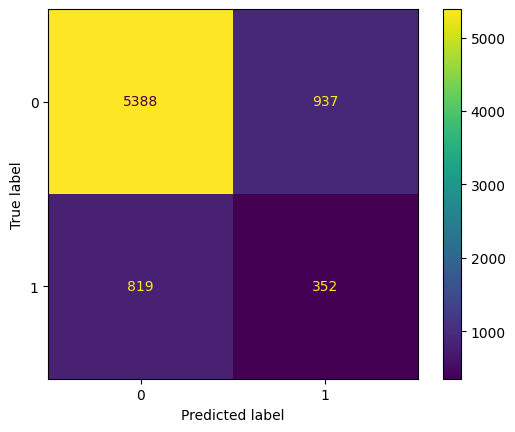

In [30]:
# Model Evaluation (Confusion Matrix & Important Metrics)
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        # Collect predictions and true labels for confusion matrix
        all_preds.extend(predicted.cpu().numpy()) # predictions
        all_labels.extend(labels.cpu().numpy()) # actual

# Calculate specific metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"\nMetrics for model evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["0", "1"]))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

# Custom credit / loan metrics
approval_rate = (fn + tn) / (tp + fp + tn + fn)
default_rate_approved = fn / (tn + fn) if (tn + fn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\nImportant loan metrics:")
print(f"Approval Rate: {approval_rate:.4f}")
print(f"Default Rate (Approved):{default_rate_approved:.4f}")
print(f"False Negative Rate: {fnr:.4f}")
print(f"Loss: {fn:.4f}")

# Display confusion matrix
cm_display = ConfusionMatrixDisplay(cm, display_labels=[0, 1])
cm_display.plot()
plt.show()

Test Loss: 0.5584
Test Accuracy: 72.53%


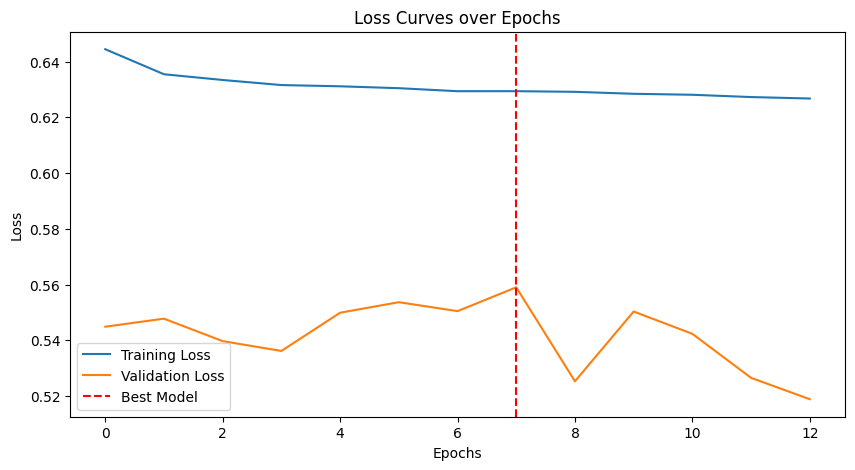

In [31]:
# Load the Best Model Weights Found During Training
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Loss: {test_loss / len(test_loader.dataset):.4f}")
print(f"Test Accuracy: {(100 * correct / total):.2f}%")

# Plotting the learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.axvline(x=len(train_losses) - epochs_no_improve - 1, color='r', linestyle='--', label='Best Model')
plt.title('Loss Curves over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [32]:
# Improving the Model

# Reset all random seeds so new model starts from same state as previous model did
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
np.random.seed(random_seed)

# Reducing dropout rate from 0.2 to 0.2
class LoansModel2(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_rate=0.2):
        super(LoansModel2, self).__init__()

# Reducing neurons from 64 & 128 to 32 & 64 to allow more gradual learning
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Output Layer
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

In [33]:
# Initialize the New Model, Loss Function, and Optimizer
model2 = LoansModel2(input_dim=X_train.shape[1], num_classes=2).to(device)

criterion2 = nn.CrossEntropyLoss()

# Reduced learning rate from 0.001 to 0.001
optimizer2 = optim.AdamW(model2.parameters(), lr=0.001, weight_decay=1e-2)

# Increasing patience from 5 to 10
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='min', factor=0.5, patience=10)

# Separating the data loader for model2 with its own generator
generator2 = torch.Generator()
generator2.manual_seed(random_seed)
train_loader2 = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True, generator=generator2)

In [34]:
# Re-defining the Training Loop
epochs2 = 100
patience2 = 10 # increasing the patience from 5 to 10 here as well
best_fnr2 = float('inf')
epochs_no_improve2 = 0
early_stop2 = False

train_losses2, val_losses2 = [], []

for epoch in range(epochs2):
    if early_stop2:
        print(f"Early stopping triggered at epoch {epoch}")
        break

    # --- Training Phase ---
    model2.train()
    running_loss2 = 0.0
    for inputs, labels in train_loader2:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer2.zero_grad()
        outputs = model2(inputs)
        loss = criterion2(outputs, labels)
        loss.backward()
        optimizer2.step()

        running_loss2 += loss.item() * inputs.size(0)

    epoch_train_loss2 = running_loss2 / len(train_loader2.dataset)
    train_losses2.append(epoch_train_loss2)

    # --- Validation Phase ---
    # Changing loss computation from batched to using the whole validation set to address class imbalance issue
    model2.eval()
    with torch.no_grad():
        val_outputs2 = model2(X_val_t.to(device))
        epoch_val_loss2 = criterion2(val_outputs2, y_val_t.to(device)).item()
        
        _, val_preds_t2 = torch.max(val_outputs2, dim=1)
        val_preds2 = val_preds_t2.cpu().numpy()
        val_labels2 = y_val_t.numpy()

    val_losses2.append(epoch_val_loss2)

    # Calculate FNR on validation set
    val_cm2 = confusion_matrix(val_labels2, val_preds2)
    tn2, fp2, fn2, tp2 = val_cm2.ravel()
    epoch_fnr2 = fn2 / (fn2 + tp2) if (fn2 + tp2) > 0 else 0

    scheduler2.step(epoch_val_loss2)

    # --- Early Stopping Logic ---
    if epoch_fnr2 < best_fnr2:
        best_fnr2 = epoch_fnr2
        epochs_no_improve2 = 0
        # new best model save file
        torch.save(model2.state_dict(), 'best_model2.pth')
    else:
        epochs_no_improve2 += 1
        if epochs_no_improve2 >= patience2:
            early_stop2 = True

# every 5 steps we will print out the current loss
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs2} | Train Loss: {epoch_train_loss2:.4f} | Val Loss: {epoch_val_loss2:.4f} | Val FNR: {epoch_fnr2:.4f}")

Epoch 005/100 | Train Loss: 0.6311 | Val Loss: 0.5499 | Val FNR: 0.6243
Epoch 010/100 | Train Loss: 0.6285 | Val Loss: 0.5503 | Val FNR: 0.6166
Epoch 015/100 | Train Loss: 0.6263 | Val Loss: 0.5378 | Val FNR: 0.6251
Early stopping triggered at epoch 18



Metrics for model2 evaluation:
Accuracy: 0.7257
Precision: 0.2548
Recall (Sensitivity): 0.3928
F1-Score: 0.3091

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      6325
           1       0.25      0.39      0.31      1171

    accuracy                           0.73      7496
   macro avg       0.56      0.59      0.57      7496
weighted avg       0.78      0.73      0.75      7496


Important loan metrics:
Approval Rate: 0.7592
Default Rate (Approved): 0.1249
False Negative Rate: 0.6072
Loss: 711.0000


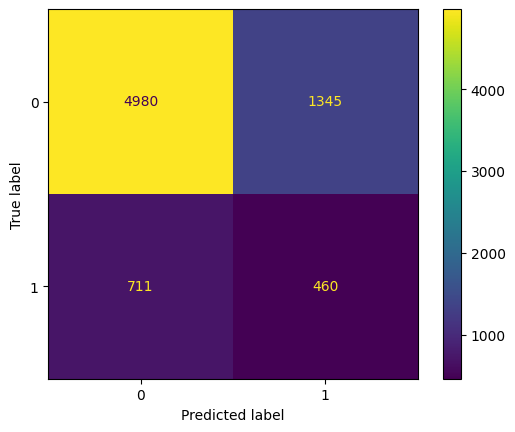

In [35]:
# Model Evaluation for New Model (Confusion Matrix & Important Metrics)
all_preds2 = []
all_labels2 = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model2(inputs)
        _, predicted = torch.max(outputs.data, 1)

        # Collect predictions and true labels for confusion matrix
        all_preds2.extend(predicted.cpu().numpy()) # predictions
        all_labels2.extend(labels.cpu().numpy()) # actuals

# Calculate specific metrics
accuracy2 = accuracy_score(all_labels2, all_preds2)
precision2 = precision_score(all_labels2, all_preds2)
recall2 = recall_score(all_labels2, all_preds2)
f1_2 = f1_score(all_labels2, all_preds2)

print(f"\nMetrics for model2 evaluation:")
print(f"Accuracy: {accuracy2:.4f}")
print(f"Precision: {precision2:.4f}")
print(f"Recall (Sensitivity): {recall2:.4f}")
print(f"F1-Score: {f1_2:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels2, all_preds2, target_names=["0", "1"]))

# Confusion matrix
cm2 = confusion_matrix(all_labels2, all_preds2)
tn2, fp2, fn2, tp2 = cm2.ravel()

# Custom credit / loan metrics
approval_rate2 = (fn2 + tn2) / (tp2 + fp2 + tn2 + fn2)
default_rate_approved2 = fn2 / (tn2 + fn2) if (tn2 + fn2) > 0 else 0
fnr2 = fn2 / (fn2 + tp2) if (fn2 + tp2) > 0 else 0

print(f"\nImportant loan metrics:")
print(f"Approval Rate: {approval_rate2:.4f}")
print(f"Default Rate (Approved): {default_rate_approved2:.4f}")
print(f"False Negative Rate: {fnr2:.4f}")
print(f"Loss: {fn2:.4f}")

# Display confusion matrix
cm_display2 = ConfusionMatrixDisplay(cm2, display_labels=[0, 1])
cm_display2.plot()
plt.show()

Test Loss: 0.5584
Test Accuracy: 72.53%


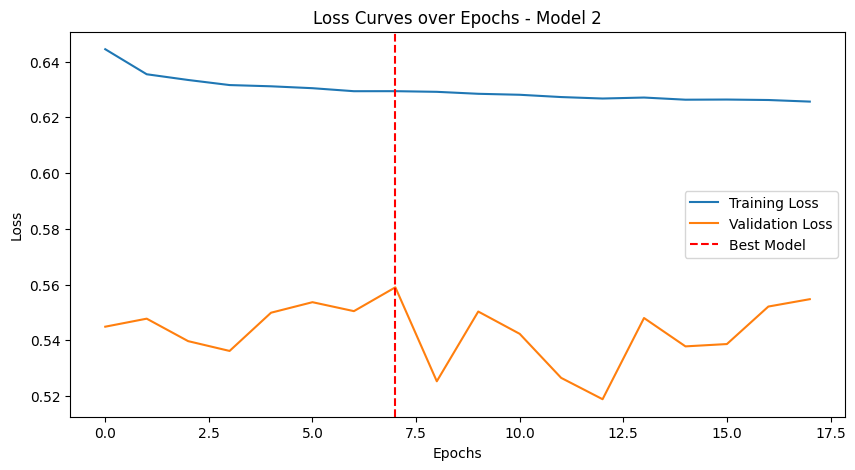

In [36]:
# Load the Best Model Weights Found During Training for New Model
model2.load_state_dict(torch.load('best_model2.pth'))  # loads from separate file
model2.eval()

correct2 = 0
total2 = 0
test_loss2 = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model2(inputs)
        loss = criterion2(outputs, labels)
        test_loss2 += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total2 += labels.size(0)
        correct2 += (predicted == labels).sum().item()

print(f"Test Loss: {test_loss2 / len(test_loader.dataset):.4f}")
print(f"Test Accuracy: {(100 * correct2 / total2):.2f}%")

# Plotting the learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses2, label='Training Loss')
plt.plot(val_losses2, label='Validation Loss')
plt.axvline(x=len(train_losses2) - epochs_no_improve2 - 1, color='r', linestyle='--', label='Best Model')
plt.title('Loss Curves over Epochs - Model 2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()